In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel('credit_card_approval_database.xlsx')
data

,Application_ID,Full_Name,Age,Gender,City,Annual_Income (INR),Employment_Type,Work_Experience (Yrs),Credit_Score,Existing_Loans,Outstanding_Loan (INR),Debt_to_Income_Ratio,Card_Type_Applied,Card_Purpose,Preferred_Bank,Approval_Status,Credit_Limit_Granted (INR)
0,CC0001,Vidhi Wason,61,Other,Jaipur,666956,Salaried,8,550,1,292632,0.44,Visa,Cashback,Axis Bank,Approved,330000
1,CC0002,Rishi Kohli,23,Male,Jaipur,324978,Salaried,6,538,4,1262524,3.88,Mastercard,Business,Yes Bank,Rejected,0
2,CC0003,Anirudh Ganesh,65,Male,Delhi,2485650,Government,7,759,4,583408,0.23,Amex,Fuel,SBI,Approved,1302000
3,CC0004,Warhi Bedi,30,Female,Surat,1103091,Business Owner,3,394,3,202828,0.18,RuPay,Travel,Yes Bank,Approved,379000
4,CC0005,Samuel Ray,50,Other,Chennai,2449103,Salaried,12,380,4,614839,0.25,Mastercard,Business,HDFC Bank,Approved,1302000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CC0496,Yutika Ahuja,65,Other,Surat,1126090,Self-Employed,1,702,3,1578820,1.40,Visa,Shopping,Axis Bank,Rejected,0
496,CC0497,Viraj Kala,39,Other,Mumbai,1853908,Self-Employed,4,644,0,997939,0.54,Amex,Fuel,HDFC Bank,Rejected,0
497,CC0498,Atharv Swaminathan,46,Male,Ahmedabad,2304798,Government,4,438,3,1172929,0.51,Amex,Business,Kotak Bank,Rejected,0
498,CC0499,Dakshesh Kurian,33,Female,Chennai,2553707,Freelancer,16,552,1,150248,0.06,Visa,Travel,Yes Bank,Approved,783000


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Application_ID              500 non-null    object 
 1   Full_Name                   500 non-null    object 
 2   Age                         500 non-null    int64  
 3   Gender                      500 non-null    object 
 4   City                        500 non-null    object 
 5   Annual_Income (INR)         500 non-null    int64  
 6   Employment_Type             500 non-null    object 
 7   Work_Experience (Yrs)       500 non-null    int64  
 8   Credit_Score                500 non-null    int64  
 9   Existing_Loans              500 non-null    int64  
 10  Outstanding_Loan (INR)      500 non-null    int64  
 11  Debt_to_Income_Ratio        500 non-null    float64
 12  Card_Type_Applied           500 non-null    object 
 13  Card_Purpose                500 non

In [4]:
data.describe()

,Age,Annual_Income (INR),Work_Experience (Yrs),Credit_Score,Existing_Loans,Outstanding_Loan (INR),Debt_to_Income_Ratio,Credit_Limit_Granted (INR)
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,5.000000e+02
mean,43.898000,1.669674e+06,9.952000,606.554000,2.452000,9.705989e+05,0.890660,4.022900e+05
std,13.509872,8.107651e+05,6.100831,168.557665,1.703379,5.585810e+05,1.042707,4.574649e+05
min,21.000000,2.030190e+05,0.000000,300.000000,0.000000,5.946000e+03,0.010000,0.000000e+00
25%,31.000000,9.688985e+05,4.000000,460.500000,1.000000,4.793685e+05,0.270000,0.000000e+00
50%,46.000000,1.661516e+06,10.000000,609.000000,2.000000,9.816205e+05,0.560000,2.720000e+05
75%,56.000000,2.375140e+06,15.000000,752.000000,4.000000,1.431766e+06,1.032500,7.145000e+05
max,65.000000,2.999565e+06,20.000000,900.000000,5.000000,1.999483e+06,7.050000,1.765000e+06


In [5]:
data.columns

Index(['Application_ID', 'Full_Name', 'Age', 'Gender', 'City',
       'Annual_Income (INR)', 'Employment_Type', 'Work_Experience (Yrs)',
       'Credit_Score', 'Existing_Loans', 'Outstanding_Loan (INR)',
       'Debt_to_Income_Ratio', 'Card_Type_Applied', 'Card_Purpose',
       'Preferred_Bank', 'Approval_Status', 'Credit_Limit_Granted (INR)'],
      dtype='object')

In [6]:
data.isnull().sum()

Application_ID                0
Full_Name                     0
Age                           0
Gender                        0
City                          0
Annual_Income (INR)           0
Employment_Type               0
Work_Experience (Yrs)         0
Credit_Score                  0
Existing_Loans                0
Outstanding_Loan (INR)        0
Debt_to_Income_Ratio          0
Card_Type_Applied             0
Card_Purpose                  0
Preferred_Bank                0
Approval_Status               0
Credit_Limit_Granted (INR)    0
dtype: int64

In [9]:
Credit_Score_By_Approval=data.groupby('Approval_Status')['Credit_Score'].value_counts().head(10)

<Axes: xlabel='Approval_Status,Credit_Score'>

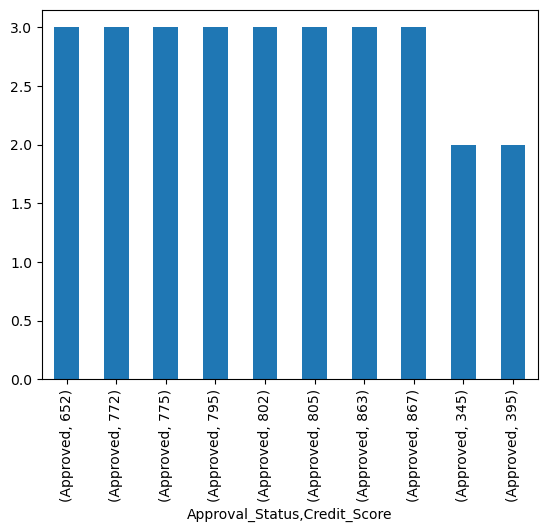

In [10]:
Credit_Score_By_Approval.plot(kind='bar')

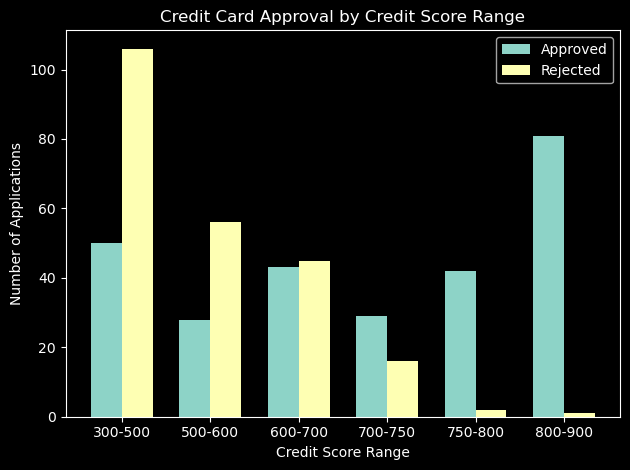

In [13]:
bins = [300, 500, 600, 700, 750, 800, 900]
labels = ['300-500', '500-600', '600-700',
          '700-750', '750-800', '800-900']

data['Score_Range'] = pd.cut(
    data['Credit_Score'],
    bins=bins,
    labels=labels
)

chart_data = pd.crosstab(
    data['Score_Range'],
    data['Approval_Status']
)

x = np.arange(len(chart_data.index))
width = 0.35

plt.bar(
    x - width/2,
    chart_data['Approved'],
    width,
    label='Approved'
)

plt.bar(
    x + width/2,
    chart_data['Rejected'],
    width,
    label='Rejected'
)

plt.xticks(x, chart_data.index)
plt.xlabel("Credit Score Range")
plt.ylabel("Number of Applications")
plt.title("Credit Card Approval by Credit Score Range")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
Approval_By_Income=data.groupby('Approval_Status')['Annual_Income (INR)'].value_counts().head()

<Axes: xlabel='Approval_Status,Annual_Income (INR)'>

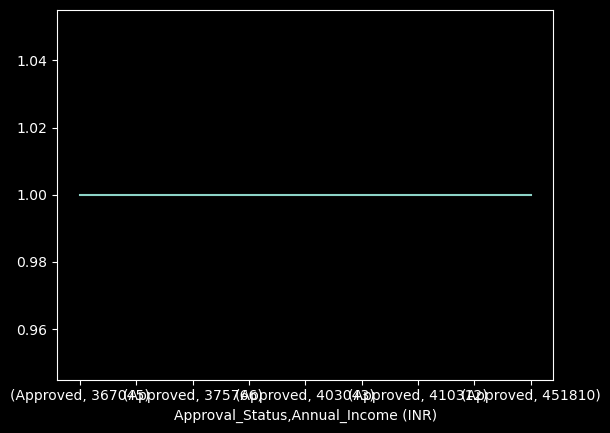

In [16]:
Approval_By_Income.plot(kind='line')

In [17]:
Approval_BY_Employment=data.groupby('Approval_Status')['Employment_Type'].value_counts().head()

Text(0.5, 0, 'Approval_Status')

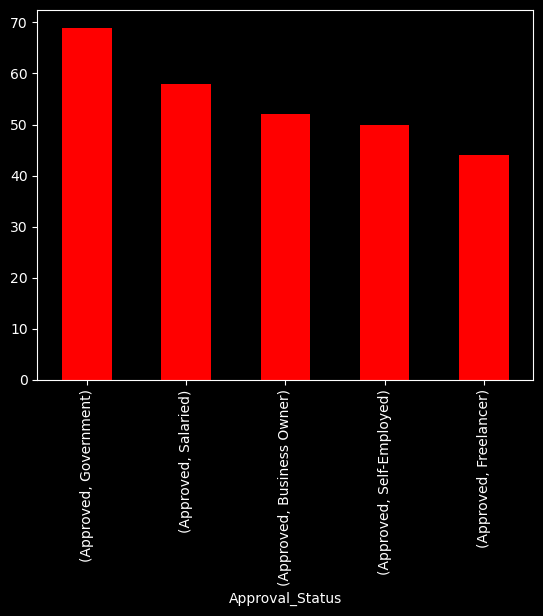

In [20]:
Approval_BY_Employment.plot(kind='bar',color='red')
plt.xlabel('Approval_Status')

<Axes: ylabel='count'>

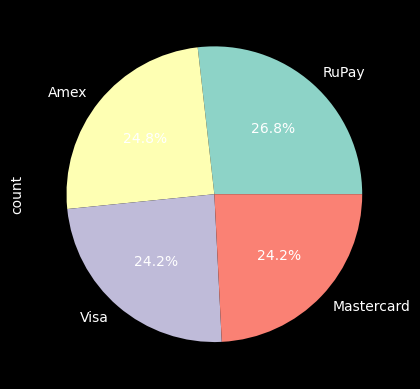

In [22]:
data['Card_Type_Applied'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: ylabel='count'>

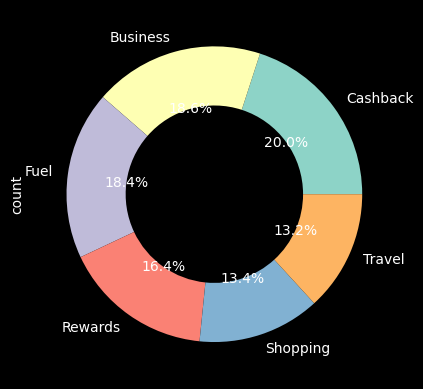

In [23]:
data['Card_Purpose'].value_counts().plot(kind='pie',autopct='%1.1f%%',wedgeprops={'width':0.4})